# EDA: данные для Aave-хеджированной Uniswap V2 ETH/USDC LP-стратегии

Этот ноутбук проверяет качество данных и готовит числовое описание для whitepaper и дальнейшего анализа.

**Цель EDA:**
1. Проверить структуру `market_data.csv`.
2. Проверить пропуски, дубли, сортировку timestamp.
3. Проанализировать ETH/USDC price.
4. Проанализировать Uniswap V2 TVL, volume и fees.
5. Проанализировать Aave/SOFR funding proxy.
6. Посчитать доходности, волатильность и regime labels.
7. Сформировать текстовые summary-блоки, которые можно отправить в чат для интерпретации.

После каждого важного графика печатается блок `COPY_THIS_TO_CHATGPT`. Его можно скопировать и прислать для анализа.

In [ ]:
from __future__ import annotations

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

PROJECT_ROOT = Path.cwd()

# Если ноутбук запускается из research/notebooks, поднимаемся к корню проекта.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "research":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "market_data.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
SUMMARY_DIR = PROJECT_ROOT / "reports" / "results_tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("FIGURES_DIR:", FIGURES_DIR)
print("SUMMARY_DIR:", SUMMARY_DIR)

PROJECT_ROOT: d:\VS\defi-lp-aave-hedge-strategy
DATA_PATH: d:\VS\defi-lp-aave-hedge-strategy\data\processed\market_data.csv
FIGURES_DIR: d:\VS\defi-lp-aave-hedge-strategy\reports\figures
SUMMARY_DIR: d:\VS\defi-lp-aave-hedge-strategy\reports\results_tables


## 1. Загрузка данных

In [ ]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").drop_duplicates("timestamp").reset_index(drop=True)

print("Shape:", df.shape)
display(df.head())
display(df.tail())

Shape: (8737, 10)


,timestamp,eth_price_usdc,uni_tvl_usd,uni_volume_usd,uni_fees_usd,uni_liquidity,aave_weth_borrow_rate,aave_usdc_supply_rate,gas_cost_usdc,regime
0,2025-01-01 00:00:00+00:00,"3,357.200000","47,010,031.110609","162,645.161772",487.935485,0.163280,0.000005,0.000005,15.000000,warmup
1,2025-01-01 01:00:00+00:00,"3,339.770000","46,923,843.264882","89,103.765218",267.311296,0.163280,0.000005,0.000005,15.000000,warmup
2,2025-01-01 02:00:00+00:00,"3,355.120000","46,968,044.849020","65,476.637925",196.429914,0.163280,0.000005,0.000005,15.000000,warmup
3,2025-01-01 03:00:00+00:00,"3,347.870000","46,989,541.383970","26,488.176689",79.464530,0.163280,0.000005,0.000005,15.000000,warmup
4,2025-01-01 04:00:00+00:00,"3,333.820000","46,907,028.087698","54,100.918678",162.302756,0.163280,0.000005,0.000005,15.000000,warmup


,timestamp,eth_price_usdc,uni_tvl_usd,uni_volume_usd,uni_fees_usd,uni_liquidity,aave_weth_borrow_rate,aave_usdc_supply_rate,gas_cost_usdc,regime
8732,2025-12-30 20:00:00+00:00,"2,956.530000","21,833,640.279007","2,002.249523",6.006749,0.072529,0.000004,0.000004,15.000000,sideways
8733,2025-12-30 21:00:00+00:00,"2,966.640000","21,821,547.991761","6,167.653250",18.502960,0.072529,0.000004,0.000004,15.000000,sideways
8734,2025-12-30 22:00:00+00:00,"2,967.240000","21,826,384.902621","4,687.100435",14.061301,0.072529,0.000004,0.000004,15.000000,sideways
8735,2025-12-30 23:00:00+00:00,"2,971.130000","21,835,396.239063","6,575.139567",19.725419,0.072529,0.000004,0.000004,15.000000,sideways
8736,2025-12-31 00:00:00+00:00,"2,963.590000","21,836,043.313416","2,628.284925",7.884855,0.072529,0.000004,0.000004,15.000000,sideways


## 2. Базовая проверка структуры и качества данных

In [ ]:
REQUIRED_COLUMNS = [
    "timestamp",
    "eth_price_usdc",
    "uni_tvl_usd",
    "uni_volume_usd",
    "uni_fees_usd",
    "uni_liquidity",
    "aave_weth_borrow_rate",
    "aave_usdc_supply_rate",
    "gas_cost_usdc",
    "regime",
]

missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
extra_cols = [c for c in df.columns if c not in REQUIRED_COLUMNS]

quality_report = {
    "rows": int(len(df)),
    "columns": int(len(df.columns)),
    "start": str(df["timestamp"].min()),
    "end": str(df["timestamp"].max()),
    "missing_required_columns": missing_cols,
    "extra_columns": extra_cols,
    "duplicate_timestamps": int(df["timestamp"].duplicated().sum()),
    "is_sorted": bool(df["timestamp"].is_monotonic_increasing),
    "missing_values_total": int(df.isna().sum().sum()),
}

print(json.dumps(quality_report, indent=2, ensure_ascii=False))

missing_by_column = df.isna().sum().sort_values(ascending=False)
display(missing_by_column.to_frame("missing_count"))

sign_checks = pd.DataFrame({
    "column": [
        "eth_price_usdc",
        "uni_tvl_usd",
        "uni_volume_usd",
        "uni_fees_usd",
        "uni_liquidity",
        "aave_weth_borrow_rate",
        "aave_usdc_supply_rate",
        "gas_cost_usdc",
    ],
    "min": [
        df["eth_price_usdc"].min(),
        df["uni_tvl_usd"].min(),
        df["uni_volume_usd"].min(),
        df["uni_fees_usd"].min(),
        df["uni_liquidity"].min(),
        df["aave_weth_borrow_rate"].min(),
        df["aave_usdc_supply_rate"].min(),
        df["gas_cost_usdc"].min(),
    ],
    "max": [
        df["eth_price_usdc"].max(),
        df["uni_tvl_usd"].max(),
        df["uni_volume_usd"].max(),
        df["uni_fees_usd"].max(),
        df["uni_liquidity"].max(),
        df["aave_weth_borrow_rate"].max(),
        df["aave_usdc_supply_rate"].max(),
        df["gas_cost_usdc"].max(),
    ],
})
display(sign_checks)

{
  "rows": 8737,
  "columns": 10,
  "start": "2025-01-01 00:00:00+00:00",
  "end": "2025-12-31 00:00:00+00:00",
  "missing_required_columns": [],
  "extra_columns": [],
  "duplicate_timestamps": 0,
  "is_sorted": true,
  "missing_values_total": 0
}


,missing_count
timestamp,0
eth_price_usdc,0
uni_tvl_usd,0
uni_volume_usd,0
uni_fees_usd,0
uni_liquidity,0
aave_weth_borrow_rate,0
aave_usdc_supply_rate,0
gas_cost_usdc,0
regime,0


,column,min,max
0,eth_price_usdc,"1,417.450000","4,934.100000"
1,uni_tvl_usd,"16,850,032.417589","112,445,938.810966"
2,uni_volume_usd,29.268577,"37,516,423.959598"
3,uni_fees_usd,0.087806,"112,549.271879"
4,uni_liquidity,0.072527,0.423236
5,aave_weth_borrow_rate,0.000004,0.000005
6,aave_usdc_supply_rate,0.000004,0.000005
7,gas_cost_usdc,15.000000,15.000000


In [ ]:
# Проверка Uniswap fees = volume * 0.003
expected_uni_fees_usd = df["uni_volume_usd"] * 0.003
fee_diff = (df["uni_fees_usd"] - expected_uni_fees_usd).abs()

fee_check = {
    "max_fee_diff": float(fee_diff.max()),
    "mean_fee_diff": float(fee_diff.mean()),
    "rows_with_fee_diff_gt_1e_6": int((fee_diff > 1e-6).sum()),
}

print(json.dumps(fee_check, indent=2, ensure_ascii=False))

{
  "max_fee_diff": 1.8189894035458565e-12,
  "mean_fee_diff": 9.67582016442012e-15,
  "rows_with_fee_diff_gt_1e_6": 0
}


## 3. Helper-функции для графиков и числовых summary

In [ ]:
def periods_per_year_from_data(data: pd.DataFrame) -> int:
    if len(data) < 3:
        return 365 * 24
    dt = data["timestamp"].sort_values().diff().dropna().dt.total_seconds().median()
    if pd.isna(dt) or dt <= 0:
        return 365 * 24
    return int(round(365 * 24 * 3600 / dt))


PERIODS_PER_YEAR = periods_per_year_from_data(df)
print("Estimated periods per year:", PERIODS_PER_YEAR)


def summarize_series(data: pd.DataFrame, column: str) -> dict:
    s = data[column].dropna()
    if s.empty:
        return {"column": column, "error": "empty series"}

    idx_min = data.loc[data[column].idxmin(), "timestamp"] if data[column].notna().any() else None
    idx_max = data.loc[data[column].idxmax(), "timestamp"] if data[column].notna().any() else None

    first_value = float(s.iloc[0])
    last_value = float(s.iloc[-1])
    pct_change = (last_value / first_value - 1) if first_value != 0 else np.nan

    return {
        "column": column,
        "count": int(s.shape[0]),
        "missing": int(data[column].isna().sum()),
        "start_value": first_value,
        "end_value": last_value,
        "total_change_pct": float(pct_change),
        "min": float(s.min()),
        "min_timestamp": str(idx_min),
        "max": float(s.max()),
        "max_timestamp": str(idx_max),
        "mean": float(s.mean()),
        "median": float(s.median()),
        "std": float(s.std(ddof=1)),
        "p01": float(s.quantile(0.01)),
        "p05": float(s.quantile(0.05)),
        "p25": float(s.quantile(0.25)),
        "p75": float(s.quantile(0.75)),
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
    }


def summarize_returns(data: pd.DataFrame, price_col: str = "eth_price_usdc") -> dict:
    ret = data[price_col].pct_change().dropna()
    if ret.empty:
        return {"error": "empty returns"}

    ann_vol = ret.std(ddof=1) * math.sqrt(PERIODS_PER_YEAR)
    ann_return = (1 + ret).prod() ** (PERIODS_PER_YEAR / len(ret)) - 1
    sharpe_like = ann_return / ann_vol if ann_vol != 0 else np.nan

    return {
        "returns_count": int(ret.shape[0]),
        "mean_period_return": float(ret.mean()),
        "median_period_return": float(ret.median()),
        "period_volatility": float(ret.std(ddof=1)),
        "annualized_return": float(ann_return),
        "annualized_volatility": float(ann_vol),
        "return_min": float(ret.min()),
        "return_p01": float(ret.quantile(0.01)),
        "return_p05": float(ret.quantile(0.05)),
        "return_p95": float(ret.quantile(0.95)),
        "return_p99": float(ret.quantile(0.99)),
        "return_max": float(ret.max()),
        "sharpe_like_no_rf": float(sharpe_like),
    }



def savefig(name: str) -> None:
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved figure: {path}")


def plot_time_series(data: pd.DataFrame, column: str, title: str, ylabel: str, filename: str) -> None:
    plt.figure(figsize=(12, 5))
    plt.plot(data["timestamp"], data[column])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    savefig(filename)
    plt.show()

Estimated periods per year: 8760


## 4. ETH/USDC price

График нужен, чтобы понять рыночный режим и силу направленного движения ETH.

Saved figure: d:\VS\defi-lp-aave-hedge-strategy\reports\figures\eda_01_eth_price.png


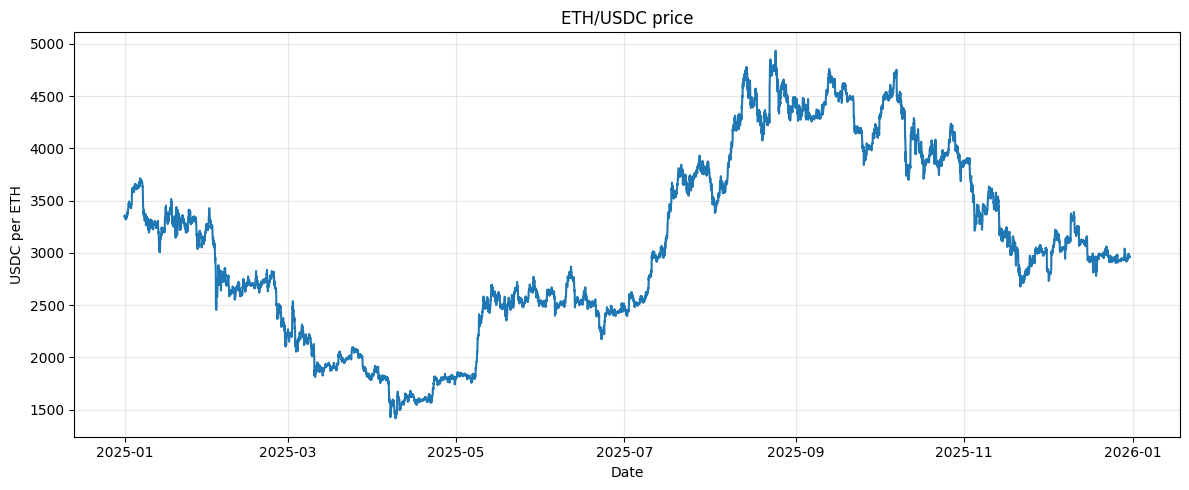

In [ ]:
plot_time_series(
    df,
    column="eth_price_usdc",
    title="ETH/USDC price",
    ylabel="USDC per ETH",
    filename="eda_01_eth_price.png",
)

### ETH/USDC price analysis

За рассматриваемый период ETH снизился с 3357.20 USDC до 2963.59 USDC, то есть примерно на 11.7%. При этом внутри периода наблюдалась высокая амплитуда движения: минимальная цена составила 1417.45 USDC 2025-04-09, а максимальная — 4934.10 USDC 2025-08-24.

Такой профиль цены важен для LP-стратегии: рынок не был монотонным, а включал сильную просадку, последующее восстановление и новый рост. Это создаёт условия, в которых plain LP может одновременно получать комиссии, но страдать от impermanent loss и directional exposure.

Для нашей стратегии это полезный тестовый период: hedge должен помогать в фазах падения ETH, но может мешать в фазах роста, поскольку borrowed WETH создаёт short ETH exposure.

## 5. ETH returns и volatility

Saved figure: d:\VS\defi-lp-aave-hedge-strategy\reports\figures\eda_02_eth_rolling_volatility.png


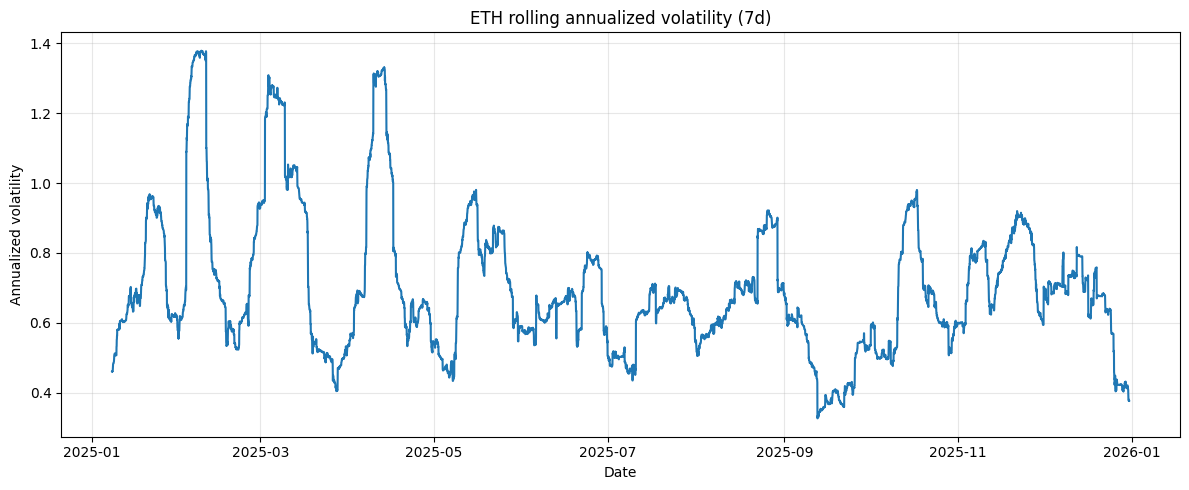

In [ ]:
df["eth_return"] = df["eth_price_usdc"].pct_change()

if PERIODS_PER_YEAR >= 365 * 24:
    rolling_window = 24 * 7
    rolling_label = "7d"
else:
    rolling_window = 30
    rolling_label = "30d"

df["rolling_eth_vol"] = df["eth_return"].rolling(rolling_window).std() * np.sqrt(PERIODS_PER_YEAR)

plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["rolling_eth_vol"])
plt.title(f"ETH rolling annualized volatility ({rolling_label})")
plt.xlabel("Date")
plt.ylabel("Annualized volatility")
plt.grid(True, alpha=0.3)
savefig("eda_02_eth_rolling_volatility.png")
plt.show()

Saved figure: d:\VS\defi-lp-aave-hedge-strategy\reports\figures\eda_03_eth_return_distribution.png


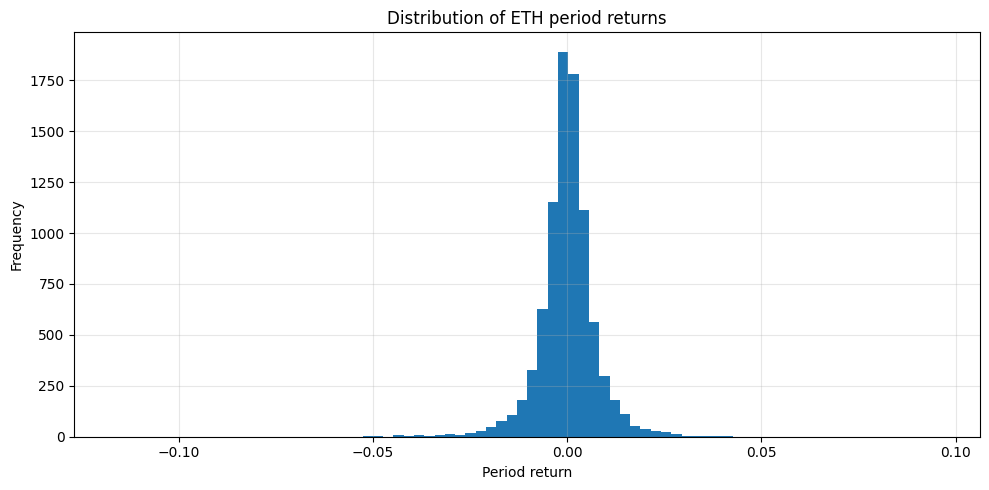

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df["eth_return"].dropna(), bins=80)
plt.title("Distribution of ETH period returns")
plt.xlabel("Period return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
savefig("eda_03_eth_return_distribution.png")
plt.show()

### ETH returns and volatility

Hourly returns ETH имеют высокую волатильность и выраженные fat tails. Средняя hourly return близка к нулю, но годовая доходность за период отрицательная: около -11.8%. Annualized volatility составила примерно 72.5%, что подтверждает высокий уровень directional risk.

Распределение hourly returns асимметрично влево: skewness около -0.37. Kurtosis около 17.2 показывает наличие экстремальных движений. Максимальное hourly падение составило -11.6%, а максимальный hourly рост — 9.6%.

Rolling 7-day annualized volatility также была нестабильной: среднее значение около 70.1%, максимум — 137.9%, минимум — 32.6%. Это подтверждает необходимость risk management: rebalance threshold, circuit breaker и ограничения по health factor.

## 6. Uniswap V2 TVL

TVL показывает ликвидность пула. Сильные провалы TVL могут ухудшать качество исполнения и увеличивать slippage.

Saved figure: d:\VS\defi-lp-aave-hedge-strategy\reports\figures\eda_04_uniswap_tvl.png


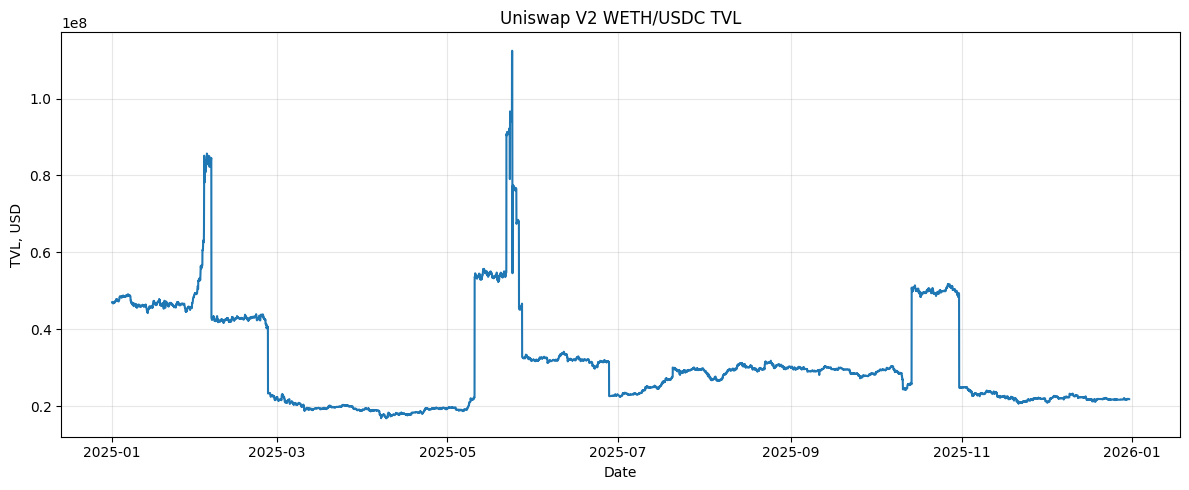

In [ ]:
plot_time_series(
    df,
    column="uni_tvl_usd",
    title="Uniswap V2 WETH/USDC TVL",
    ylabel="TVL, USD",
    filename="eda_04_uniswap_tvl.png",
)

### Uniswap V2 TVL analysis

TVL Uniswap V2 WETH/USDC pool снизился с 47.0 млн USD до 21.8 млн USD, то есть примерно на 53.6%. Средний TVL составил около 31.3 млн USD, медианный — около 29.0 млн USD. Минимальный TVL был 16.85 млн USD, максимальный — 112.45 млн USD.

С одной стороны, пул остаётся достаточно ликвидным для research-backtest: TVL почти всегда находится в десятках миллионов долларов. С другой стороны, снижение TVL показывает, что Uniswap V2 WETH/USDC уже не является самым доминирующим venue для ETH/USDC liquidity. Это важно учитывать как limitation: стратегия тестируется на классическом V2-пуле, но в реальном deployment часть ликвидности могла бы быть в Uniswap V3 или других DEX.

## 7. Uniswap V2 volume

Volume важен, потому что LP fees напрямую считаются как `volume × 0.003`.

Saved figure: d:\VS\defi-lp-aave-hedge-strategy\reports\figures\eda_05_uniswap_volume.png


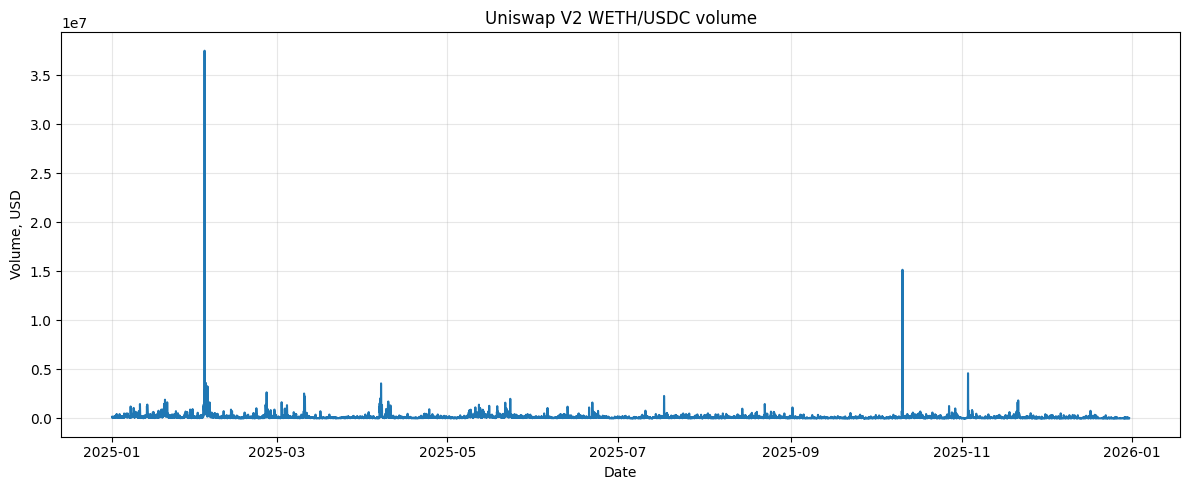

In [ ]:
plot_time_series(
    df,
    column="uni_volume_usd",
    title="Uniswap V2 WETH/USDC volume",
    ylabel="Volume, USD",
    filename="eda_05_uniswap_volume.png",
)

## 8. Estimated Uniswap LP fees

`uni_fees_usd = uni_volume_usd × 0.003`. Это общий fee pool, не доход нашей стратегии. Доход стратегии будет пропорционален её доле в пуле.

Saved figure: d:\VS\defi-lp-aave-hedge-strategy\reports\figures\eda_06_uniswap_fees.png


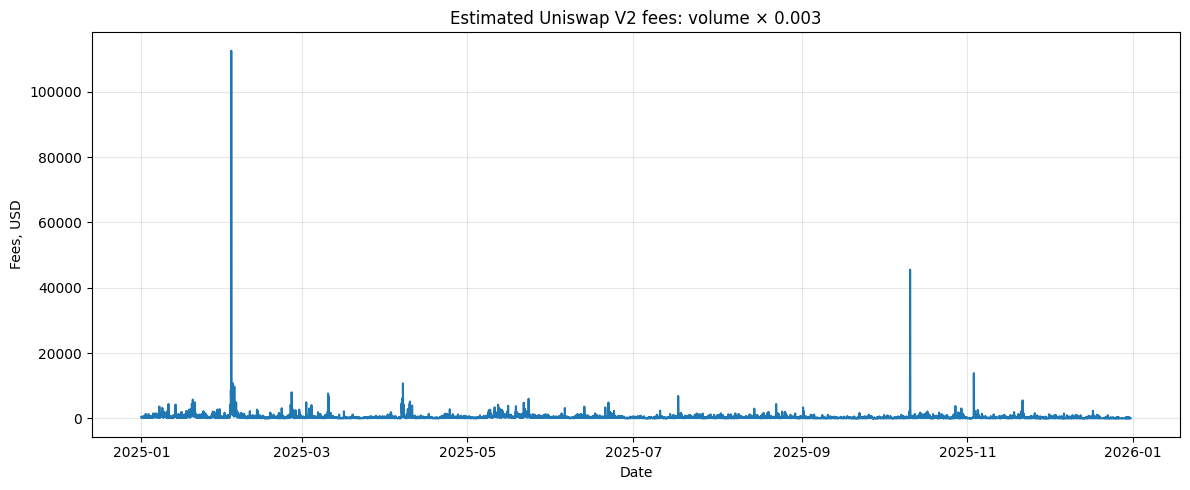

In [ ]:
plot_time_series(
    df,
    column="uni_fees_usd",
    title="Estimated Uniswap V2 fees: volume × 0.003",
    ylabel="Fees, USD",
    filename="eda_06_uniswap_fees.png",
)

### Uniswap volume and fee income

Общий торговый объём за период составил около 1.15 млрд USD. При fee rate 0.30% это даёт около 3.45 млн USD совокупных pool fees. Средний hourly volume составил около 131.4 тыс. USD, медианный — около 65.2 тыс. USD. Распределение объёма сильно скошено: максимум hourly volume составил 37.5 млн USD, тогда как 99-й перцентиль — около 949 тыс. USD.

Estimated pool fees имеют аналогичный профиль: средние hourly fees составили около 394 USD, медианные — около 196 USD, но максимум достигал 112.5 тыс. USD. Это означает, что существенная часть fee income может приходиться на отдельные всплески объёма.

Для LP-стратегии это важно: доходность plain LP и hedged LP будет сильно зависеть от того, какую долю пула занимает стратегия и попадает ли она в периоды повышенного объёма.

## 9. Volume / TVL ratio

Volume/TVL помогает понять fee intensity пула. Чем выше volume относительно TVL, тем потенциально выше fee yield для LP.

Saved figure: d:\VS\defi-lp-aave-hedge-strategy\reports\figures\eda_07_volume_tvl_ratio.png


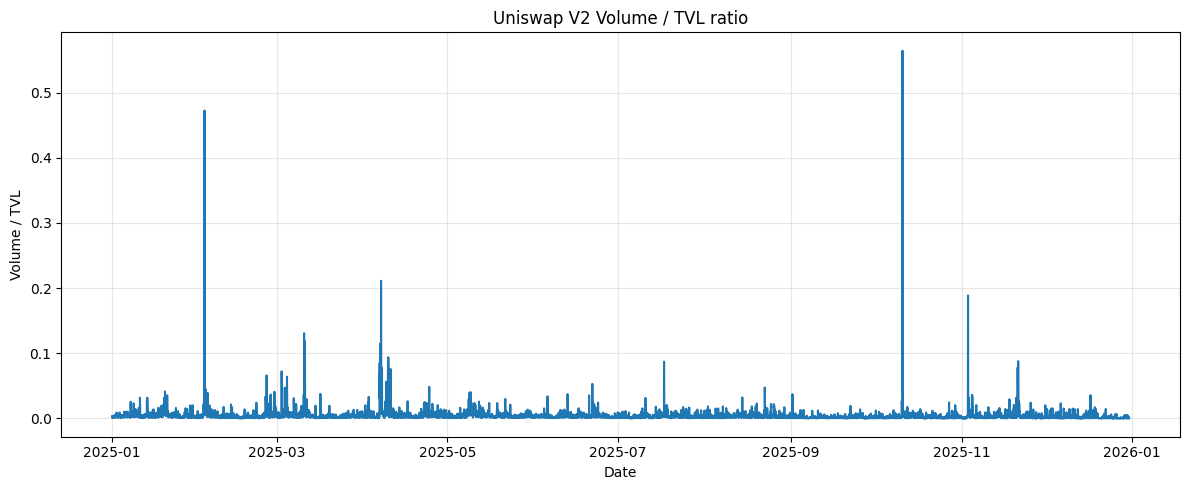

In [ ]:
df["volume_tvl_ratio"] = df["uni_volume_usd"] / df["uni_tvl_usd"]

plot_time_series(
    df,
    column="volume_tvl_ratio",
    title="Uniswap V2 Volume / TVL ratio",
    ylabel="Volume / TVL",
    filename="eda_07_volume_tvl_ratio.png",
)

### Volume / TVL ratio

Средний hourly Volume/TVL ratio составил около 0.41%, медианный — около 0.23%. При этом распределение имеет сильные выбросы: 95-й перцентиль равен 1.18%, 99-й — 2.90%, максимум — 56.4%.

Volume/TVL ratio показывает, насколько активно используется пул относительно размера ликвидности. Для LP это proxy fee intensity: чем выше volume относительно TVL, тем больше потенциальные fees на единицу предоставленной ликвидности.

Однако экстремальные значения требуют осторожности. Максимальный Volume/TVL ratio может быть связан с резким всплеском trading activity или особенностями subgraph data. Поэтому в коде и EDA полезно отдельно вывести top-10 наблюдений по Volume/TVL и проверить, не являются ли они data anomalies.

## 10. Aave / SOFR funding proxy

В данных ставки хранятся как per-period rates. Для интерпретации переводим их обратно в annualized APY.

Saved figure: d:\VS\defi-lp-aave-hedge-strategy\reports\figures\eda_08_aave_funding_proxy.png


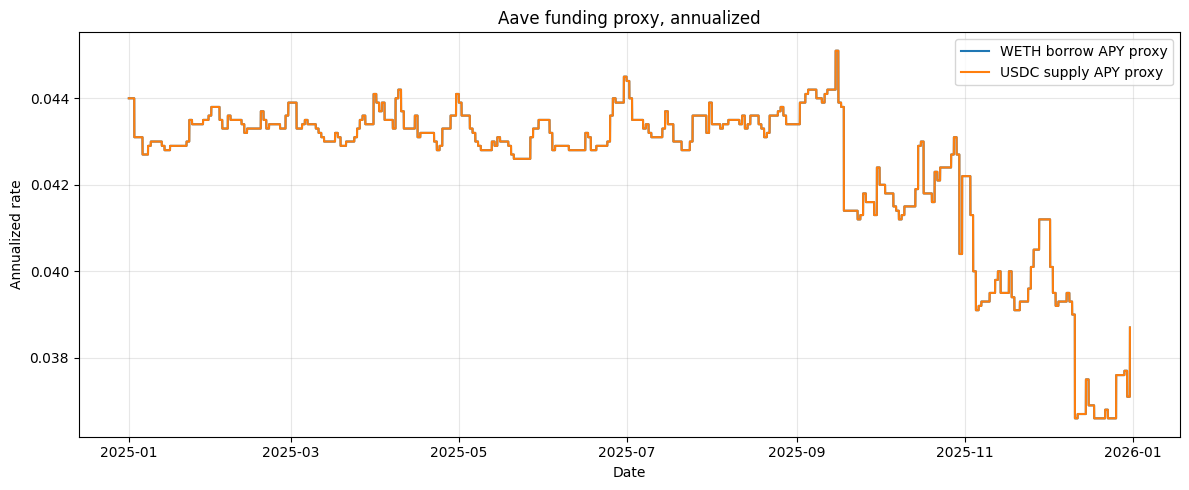

In [ ]:
df["aave_weth_borrow_apy"] = df["aave_weth_borrow_rate"] * PERIODS_PER_YEAR
df["aave_usdc_supply_apy"] = df["aave_usdc_supply_rate"] * PERIODS_PER_YEAR
df["net_funding_spread_apy"] = df["aave_weth_borrow_apy"] - df["aave_usdc_supply_apy"]

plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["aave_weth_borrow_apy"], label="WETH borrow APY proxy")
plt.plot(df["timestamp"], df["aave_usdc_supply_apy"], label="USDC supply APY proxy")
plt.title("Aave funding proxy, annualized")
plt.xlabel("Date")
plt.ylabel("Annualized rate")
plt.legend()
plt.grid(True, alpha=0.3)
savefig("eda_08_aave_funding_proxy.png")
plt.show()

### Aave/SOFR funding proxy

Исторические Aave WETH borrow и USDC supply rates не удалось стабильно получить из публичных источников, поэтому в текущем dataset используется SOFR-based funding proxy. Средний annualized proxy rate составил около 4.23%, медиана — 4.31%, максимум — 4.51%.

В текущей базовой версии WETH borrow APY и USDC supply APY заданы одинаковыми через SOFR proxy, поэтому net funding spread равен нулю. Это упрощающее допущение: в реальном Aave WETH borrow rate и USDC supply rate отличались бы из-за utilization, risk parameters и состояния конкретных reserves.

Такой подход делает funding assumption воспроизводимым и не произвольным, но требует sensitivity analysis. В следующих backtest-запусках желательно проверить сценарии со spread над SOFR, например:
- base: WETH borrow = SOFR, USDC supply = SOFR;
- conservative: WETH borrow = SOFR + 2%, USDC supply = SOFR;
- stress: WETH borrow = SOFR + 5%, USDC supply = SOFR.

## 11. Regime labels

Режимы нужны для отдельной оценки стратегии: uptrend, downtrend, sideways, high-volatility chop и т.д.

,count,share
regime,,
sideways,5758,0.659036
high_vol_chop,1573,0.180039
uptrend,713,0.081607
downtrend,669,0.076571
warmup,24,0.002747


Saved figure: d:\VS\defi-lp-aave-hedge-strategy\reports\figures\eda_09_regime_distribution.png


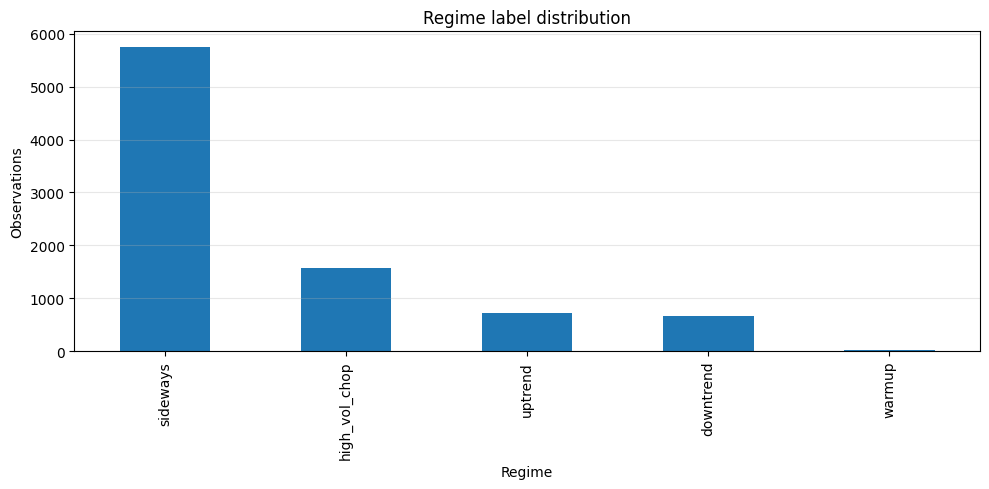

In [ ]:
regime_counts = df["regime"].value_counts(dropna=False).to_frame("count")
regime_counts["share"] = regime_counts["count"] / len(df)
display(regime_counts)

plt.figure(figsize=(10, 5))
regime_counts["count"].plot(kind="bar")
plt.title("Regime label distribution")
plt.xlabel("Regime")
plt.ylabel("Observations")
plt.grid(True, axis="y", alpha=0.3)
savefig("eda_09_regime_distribution.png")
plt.show()

In [ ]:
df["regime_shift"] = df["regime"].ne(df["regime"].shift())
df["regime_segment_id"] = df["regime_shift"].cumsum()

segments = (
    df.groupby(["regime_segment_id", "regime"])
    .agg(
        start=("timestamp", "min"),
        end=("timestamp", "max"),
        observations=("timestamp", "count"),
        eth_start=("eth_price_usdc", "first"),
        eth_end=("eth_price_usdc", "last"),
        fees_sum=("uni_fees_usd", "sum"),
        volume_sum=("uni_volume_usd", "sum"),
        avg_vol=("eth_return", "std"),
    )
    .reset_index()
)

segments["eth_change_pct"] = segments["eth_end"] / segments["eth_start"] - 1

display(
    segments
    .sort_values("observations", ascending=False)
    .head(20)
)

,regime_segment_id,regime,start,end,observations,eth_start,eth_end,fees_sum,volume_sum,avg_vol,eth_change_pct
632,633,sideways,2025-12-20 03:00:00+00:00,2025-12-31 00:00:00+00:00,262,"2,988.300000","2,963.590000","16,797.980282","5,599,326.760700",0.004152,-0.008269
452,453,sideways,2025-09-13 04:00:00+00:00,2025-09-22 04:00:00+00:00,217,"4,745.720000","4,293.080000","24,886.170714","8,295,390.238063",0.004080,-0.095379
236,237,sideways,2025-04-23 21:00:00+00:00,2025-05-01 13:00:00+00:00,185,"1,792.320000","1,826.940000","51,955.577868","17,318,525.955919",0.005798,0.019316
238,239,sideways,2025-05-01 17:00:00+00:00,2025-05-08 05:00:00+00:00,157,"1,856.660000","1,896.540000","28,533.402854","9,511,134.284807",0.005256,0.021479
448,449,sideways,2025-09-06 14:00:00+00:00,2025-09-12 18:00:00+00:00,149,"4,296.790000","4,627.520000","17,546.325411","5,848,775.137045",0.003591,0.076971
373,374,sideways,2025-07-26 02:00:00+00:00,2025-08-01 05:00:00+00:00,148,"3,743.170000","3,675.300000","34,863.085765","11,621,028.588499",0.005185,-0.018132
341,342,sideways,2025-07-03 15:00:00+00:00,2025-07-09 18:00:00+00:00,148,"2,571.260000","2,718.900000","19,860.508686","6,620,169.562158",0.004733,0.057419
337,338,sideways,2025-06-24 22:00:00+00:00,2025-06-30 14:00:00+00:00,137,"2,442.670000","2,439.360000","25,835.463353","8,611,821.117548",0.005064,-0.001355
595,596,sideways,2025-11-25 17:00:00+00:00,2025-11-30 23:00:00+00:00,127,"2,935.840000","2,992.250000","14,218.334796","4,739,444.932008",0.005610,0.019214
176,177,sideways,2025-03-14 18:00:00+00:00,2025-03-19 10:00:00+00:00,113,"1,935.430000","1,973.690000","16,513.550640","5,504,516.880004",0.004879,0.019768


In [ ]:
segment_summary = (
    segments.groupby("regime")
    .agg(
        segments_count=("regime_segment_id", "count"),
        avg_segment_length=("observations", "mean"),
        median_segment_length=("observations", "median"),
        avg_segment_return=("eth_change_pct", "mean"),
        median_segment_return=("eth_change_pct", "median"),
        total_fees=("fees_sum", "sum"),
    )
    .reset_index()
)

display(segment_summary)

,regime,segments_count,avg_segment_length,median_segment_length,avg_segment_return,median_segment_return,total_fees
0,downtrend,106,6.311321,2.000000,-0.005131,0.000000,"889,072.462991"
1,high_vol_chop,196,8.025510,5.000000,0.002184,0.000000,"794,900.198637"
2,sideways,209,27.550239,9.000000,-0.000372,0.000000,"1,393,171.234222"
3,uptrend,121,5.892562,2.000000,0.004502,0.000000,"360,529.946683"
4,warmup,1,24.000000,24.000000,-0.001188,-0.001188,"7,379.176396"


### Regime segments analysis

После перехода от простой группировки по regime к анализу непрерывных regime segments видно, что рыночные режимы часто переключаются. Это особенно заметно для directional regimes: downtrend имеет 106 сегментов со средней длиной около 6.3 часа и медианной длиной 2 часа, а uptrend имеет 121 сегмент со средней длиной около 5.9 часа и медианной длиной 2 часа. Это означает, что directional moves в данных часто являются короткими импульсами, а не длинными устойчивыми трендами.

Sideways regime является наиболее устойчивым: 209 сегментов, средняя длина около 27.6 часа, медианная длина 9 часов. Это подтверждает, что основная часть периода действительно состоит из относительно спокойных или боковых участков, где LP-стратегия потенциально может зарабатывать комиссии без сильного directional loss.

High-volatility chop занимает промежуточное положение: 196 сегментов со средней длиной около 8 часов. Для нашей стратегии это важный режим, потому что в нём LP может получать повышенные fees, но частый hedge rebalance может увеличить gas и slippage costs.

In [ ]:
regime_numeric = (
    df.groupby("regime", dropna=False)
    .agg(
        observations=("timestamp", "count"),
        start=("timestamp", "min"),
        end=("timestamp", "max"),
        eth_start=("eth_price_usdc", "first"),
        eth_end=("eth_price_usdc", "last"),
        eth_mean=("eth_price_usdc", "mean"),
        eth_return_mean=("eth_return", "mean"),
        eth_return_std=("eth_return", "std"),
        tvl_mean=("uni_tvl_usd", "mean"),
        volume_mean=("uni_volume_usd", "mean"),
        fees_sum=("uni_fees_usd", "sum"),
        volume_tvl_ratio_mean=("volume_tvl_ratio", "mean"),
        weth_borrow_apy_mean=("aave_weth_borrow_apy", "mean"),
        usdc_supply_apy_mean=("aave_usdc_supply_apy", "mean"),
    )
    .reset_index()
)

regime_numeric["eth_total_change_pct"] = regime_numeric["eth_end"] / regime_numeric["eth_start"] - 1
regime_numeric["eth_ann_vol_est"] = regime_numeric["eth_return_std"] * np.sqrt(PERIODS_PER_YEAR)

display(regime_numeric)
regime_numeric.to_csv(SUMMARY_DIR / "eda_regime_summary.csv", index=False)
print(f"Saved regime summary: {SUMMARY_DIR / 'eda_regime_summary.csv'}")

,regime,observations,start,end,eth_start,eth_end,eth_mean,eth_return_mean,eth_return_std,tvl_mean,volume_mean,fees_sum,volume_tvl_ratio_mean,weth_borrow_apy_mean,usdc_supply_apy_mean,eth_total_change_pct,eth_ann_vol_est
0,downtrend,669,2025-01-07 15:00:00+00:00,2025-12-16 13:00:00+00:00,"3,461.200000","2,910.400000","2,810.257429",-0.002646,0.013280,"31,657,428.980542","442,985.781261","889,072.462991",0.012916,0.042350,0.042350,-0.159136,1.242944
1,high_vol_chop,1573,2025-01-09 15:00:00+00:00,2025-12-19 16:00:00+00:00,"3,319.600000","2,965.930000","2,974.157222",0.000187,0.009600,"34,522,036.913719","168,446.746903","794,900.198637",0.004811,0.042268,0.042268,-0.106540,0.898481
2,sideways,5758,2025-01-02 00:00:00+00:00,2025-12-31 00:00:00+00:00,"3,383.220000","2,963.590000","3,124.318699",-0.000017,0.005539,"30,440,573.984494","80,651.339251","1,393,171.234222",0.002647,0.042447,0.042447,-0.124033,0.518410
3,uptrend,713,2025-01-03 22:00:00+00:00,2025-12-20 02:00:00+00:00,"3,614.950000","2,981.600000","3,046.559930",0.002399,0.010342,"30,088,961.588966","168,550.699711","360,529.946683",0.005887,0.042606,0.042606,-0.175203,0.967927
4,warmup,24,2025-01-01 00:00:00+00:00,2025-01-01 23:00:00+00:00,"3,357.200000","3,353.210000","3,341.948333",-0.000048,0.002640,"46,920,592.387591","102,488.561062","7,379.176396",0.002183,0.044000,0.044000,-0.001188,0.247079


Saved regime summary: d:\VS\defi-lp-aave-hedge-strategy\reports\results_tables\eda_regime_summary.csv


### Fee income by regime

Хотя sideways regime занимает около 66% всех наблюдений и даёт наибольшую сумму fees в абсолютном выражении — около 1.39 млн USD pool-level fees, fee intensity в нём относительно низкая. В среднем sideways даёт около 242 USD pool fees в час.

Downtrend занимает только около 7.7% наблюдений, но даёт около 889 тыс. USD pool-level fees. Это означает примерно 1329 USD pool fees в час, что существенно выше, чем в sideways. High-volatility chop даёт около 795 тыс. USD fees при 1573 наблюдениях, то есть примерно 505 USD в час. Uptrend даёт около 361 тыс. USD fees при 713 наблюдениях, то есть около 506 USD в час.

Это важный вывод: fee income концентрируется не только в спокойных режимах, но и в стрессовых/downtrend эпизодах. Поэтому hedge может быть особенно полезен, если он снижает directional losses именно в тех режимах, где trading volume и fee income повышены.

## 12. Correlation overview

Корреляции нужны, чтобы понять связь между ценой ETH, объёмом, fees, TVL и funding proxy.

,eth_price_usdc,eth_return,uni_tvl_usd,uni_volume_usd,uni_fees_usd,volume_tvl_ratio,aave_weth_borrow_apy,aave_usdc_supply_apy,net_funding_spread_apy
eth_price_usdc,1.000000,0.011986,0.224657,-0.034364,-0.034364,-0.091850,-0.095829,-0.095829,NaN
eth_return,0.011986,1.000000,-0.006045,-0.093875,-0.093875,-0.091294,0.009160,0.009160,NaN
uni_tvl_usd,0.224657,-0.006045,1.000000,0.163475,0.163475,0.025299,0.212435,0.212435,NaN
uni_volume_usd,-0.034364,-0.093875,0.163475,1.000000,1.000000,0.845247,0.049683,0.049683,NaN
uni_fees_usd,-0.034364,-0.093875,0.163475,1.000000,1.000000,0.845247,0.049683,0.049683,NaN
volume_tvl_ratio,-0.091850,-0.091294,0.025299,0.845247,0.845247,1.000000,0.050930,0.050930,NaN
aave_weth_borrow_apy,-0.095829,0.009160,0.212435,0.049683,0.049683,0.050930,1.000000,1.000000,NaN
aave_usdc_supply_apy,-0.095829,0.009160,0.212435,0.049683,0.049683,0.050930,1.000000,1.000000,NaN
net_funding_spread_apy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved figure: d:\VS\defi-lp-aave-hedge-strategy\reports\figures\eda_10_correlation_matrix.png


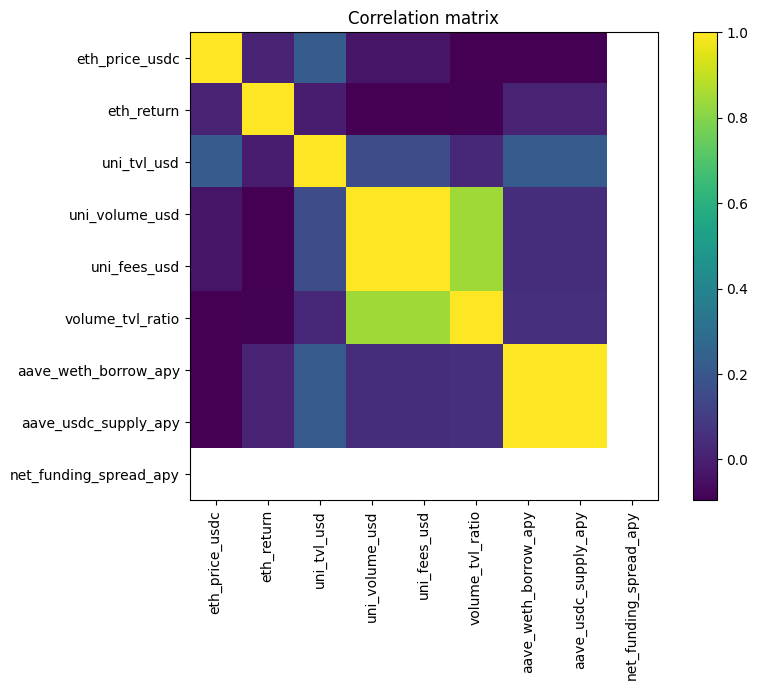

Saved correlation matrix: d:\VS\defi-lp-aave-hedge-strategy\reports\results_tables\eda_correlation_matrix.csv


In [ ]:
corr_cols = [
    "eth_price_usdc",
    "eth_return",
    "uni_tvl_usd",
    "uni_volume_usd",
    "uni_fees_usd",
    "volume_tvl_ratio",
    "aave_weth_borrow_apy",
    "aave_usdc_supply_apy",
]

corr_df = df[corr_cols].corr(numeric_only=True)
display(corr_df)

plt.figure(figsize=(9, 7))
plt.imshow(corr_df)
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.colorbar()
plt.title("Correlation matrix")
savefig("eda_10_correlation_matrix.png")
plt.show()

corr_df.to_csv(SUMMARY_DIR / "eda_correlation_matrix.csv")
print(f"Saved correlation matrix: {SUMMARY_DIR / 'eda_correlation_matrix.csv'}")

### Correlation analysis

Correlation matrix показывает несколько ожидаемых зависимостей. Uniswap volume и estimated fees имеют корреляцию 1.0, потому что fees рассчитываются напрямую как volume × 0.003. Volume также сильно связан с Volume/TVL ratio: корреляция около 0.845.

ETH price слабо связан с Uniswap volume и fees: корреляция около -0.034. Это значит, что fee income в данном dataset не определяется только уровнем цены ETH. Для стратегии это важно: LP fees могут возникать как в росте, так и в падении, особенно в периоды повышенной торговой активности.

TVL умеренно положительно связан с ETH price: корреляция около 0.225. Это ожидаемо, потому что часть TVL выражена через стоимость ETH.

Aave WETH borrow APY и USDC supply APY имеют корреляцию 1.0, потому что в текущей версии оба ряда построены на одном SOFR proxy. Поэтому correlation с funding proxy не должна интерпретироваться как реальная связь Aave rates с market variables.

## 13. Backtest readiness summary

Этот блок собирает финальное числовое описание, которое удобно прислать для анализа.

In [ ]:
readiness_summary = {
    "dataset": {
        "path": str(DATA_PATH),
        "rows": int(len(df)),
        "start": str(df["timestamp"].min()),
        "end": str(df["timestamp"].max()),
        "periods_per_year_estimate": PERIODS_PER_YEAR,
        "duplicate_timestamps": int(df["timestamp"].duplicated().sum()),
        "missing_values_total": int(df[REQUIRED_COLUMNS].isna().sum().sum()),
    },
    "eth_price": summarize_series(df, "eth_price_usdc"),
    "eth_returns": summarize_returns(df, "eth_price_usdc"),
    "uniswap_tvl": summarize_series(df, "uni_tvl_usd"),
    "uniswap_volume": summarize_series(df, "uni_volume_usd"),
    "uniswap_fees": {
        **summarize_series(df, "uni_fees_usd"),
        "total_pool_fees_usd": float(df["uni_fees_usd"].sum()),
        "total_volume_usd": float(df["uni_volume_usd"].sum()),
    },
    "volume_tvl_ratio": summarize_series(df, "volume_tvl_ratio"),
    "funding_proxy": {
        "weth_borrow_apy": summarize_series(df, "aave_weth_borrow_apy"),
        "usdc_supply_apy": summarize_series(df, "aave_usdc_supply_apy"),
        "net_funding_spread_apy": summarize_series(df, "net_funding_spread_apy"),
    },
    "regime_counts": regime_counts.reset_index().to_dict(orient="records"),
}

summary_path = SUMMARY_DIR / "eda_numeric_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(readiness_summary, f, ensure_ascii=False, indent=2)

print(f"Saved numeric summary: {summary_path}")

Saved numeric summary: d:\VS\defi-lp-aave-hedge-strategy\reports\results_tables\eda_numeric_summary.json


## Общая оценка качества данных

Итоговый датасет содержит 8737 hourly-наблюдений за период с 2025-01-01 00:00 UTC по 2025-12-31 00:00 UTC. В данных нет пропусков и дубликатов timestamp, что делает датасет технически пригодным для backtest.

Основные рыночные данные включают ETH/USDC price, Uniswap V2 WETH/USDC TVL, volume, estimated pool fees, Aave/SOFR funding proxy и regime labels. Данные синхронизированы по hourly timestamp.

Главное ограничение датасета — ставки Aave. Исторические Aave WETH borrow и USDC supply rates не удалось стабильно получить из публичных API, поэтому в текущей версии используется SOFR-based funding proxy. Это делает funding assumptions воспроизводимыми, но не полностью отражающими реальные Aave reserve dynamics.